# Day 09: vLLM — PagedAttention & Continuous Batching
> *100 Days of Inference* | Layer: **Runtime** | Book: *Inference Engineering* Ch 4.3.1 (pp. 106–108)

**Prerequisite:** Day 08 (model formats)

**Goal:** Understand how vLLM achieves high throughput through PagedAttention (KV cache memory management) and continuous batching.

## What problem does this solve?

Naive LLM serving has terrible GPU memory utilization. When a request arrives, the output length is unknown. Either the system pre-allocates maximum possible KV cache memory (wasteful — most requests are short) or extends memory on the fly (fragmentation — same problem as heap allocation without a good allocator).

Worse: early inference systems processed one request at a time. While one request generated tokens, the GPU sat idle for all other pending requests.

vLLM solved both problems: PagedAttention (like virtual memory paging for the KV cache) and continuous batching (no more waiting — new requests join mid-flight).

**Infrastructure analogy:** Pre-vLLM serving is like a web server that handles one HTTP request at a time and reserves 1 GB of RAM upfront for every request regardless of actual size. vLLM is async with dynamic memory allocation — handles thousands of concurrent requests, each using exactly the memory it needs.

## Concept Overview

**vLLM** is the most popular open-source LLM inference engine (as of 2025). Two core innovations:

### PagedAttention
Inspired by OS virtual memory paging. Instead of storing the KV cache for each request in one contiguous memory block, PagedAttention divides the KV cache into fixed-size **pages** (blocks). A **block table** maps logical pages to physical memory locations — the KV cache can be stored in non-contiguous memory.

Benefits:
- **No fragmentation:** Pages are fixed-size, no unusable gaps
- **Sharing:** Multiple requests sharing the same prefix can share physical pages (prefix caching)
- **Near-zero waste:** Allocate pages on demand; free them immediately when the request finishes

### Continuous Batching
Instead of static batching (wait for a full batch, run it, discard), continuous batching iterates at the **token level**. After each token generation step, any request that finished is swapped out and a new request is swapped in. The batch is always full.

**Infrastructure analogy:** Static batching = batch job processing (collect work, run it, repeat). Continuous batching = an async event loop — always running, requests join and leave dynamically.

In [1]:
!pip install -q numpy matplotlib torch 2>/dev/null
import numpy as np
import matplotlib.pyplot as plt
import torch
import time
from collections import deque
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA GB10
GPU Memory: 128.5 GB


## Part 1: The KV Cache Memory Problem

Before PagedAttention, inference engines allocated a contiguous block of memory for the KV cache per request. The problem: output length is unknown at request time, so the system must pre-allocate for the maximum possible output.

**KV cache size formula:**
$$\text{KV cache (bytes)} = 2 \times \text{layers} \times \text{heads} \times d_{head} \times \text{seq\_len} \times \text{bytes\_per\_value}$$

The `2` is for K and V. For a typical LLM (32 layers, 32 heads, d=128, FP16):
- At seq_len=512: ~2 GB per request
- At seq_len=4096: ~16 GB per request

A single long request can consume more memory than the model weights themselves.

In [2]:
def kv_cache_size(layers, heads, d_head, seq_len, bytes_per_val=2):
    """Calculate KV cache memory in bytes."""
    #2 = K and V, each is (layers, heads, seq_len, d_head)
    return 2 * layers * heads * d_head * seq_len * bytes_per_val

# Common model configurations
model_configs = {
    "LLaMA 3 8B":    {"layers": 32, "heads": 8, "d_head": 128},   # GQA: 8 KV heads
    "LLaMA 3 70B":   {"layers": 80, "heads": 8, "d_head": 128},   # GQA: 8 KV heads
    "Mistral 7B":    {"layers": 32, "heads": 8, "d_head": 128},
    "GPT-4 class":   {"layers": 96, "heads": 16, "d_head": 128},
}

seq_lengths = [512, 1024, 2048, 4096, 8192, 16384, 32768]

print("KV cache size per request (GB)")
print(f"{'Model':<18} " + " ".join(f"{s:>7}" for s in ["512","1K","2K","4K","8K","16K","32K"]))
print("-" * 80)
for name, cfg in model_configs.items():
    sizes = [kv_cache_size(cfg["layers"], cfg["heads"], cfg["d_head"], s) / 1e9
             for s in seq_lengths]
    print(f"{name:<18} " + " ".join(f"{s:>6.2f}G" for s in sizes))

print(f"\nNote: H100 SXM has 80 GB VRAM.")
print(f"LLaMA 3 70B weights in FP16 = ~140 GB (need 2+ GPUs just for weights)")
print(f"Every request's KV cache adds to that budget.")

KV cache size per request (GB)
Model                  512      1K      2K      4K      8K     16K     32K
--------------------------------------------------------------------------------
LLaMA 3 8B           0.07G   0.13G   0.27G   0.54G   1.07G   2.15G   4.29G
LLaMA 3 70B          0.17G   0.34G   0.67G   1.34G   2.68G   5.37G  10.74G
Mistral 7B           0.07G   0.13G   0.27G   0.54G   1.07G   2.15G   4.29G
GPT-4 class          0.40G   0.81G   1.61G   3.22G   6.44G  12.88G  25.77G

Note: H100 SXM has 80 GB VRAM.
LLaMA 3 70B weights in FP16 = ~140 GB (need 2+ GPUs just for weights)
Every request's KV cache adds to that budget.


## Part 2: PagedAttention — Virtual Memory for KV Cache

PagedAttention divides the KV cache into fixed-size **blocks** (pages). Instead of one contiguous allocation per request, the KV cache is built from blocks that can live anywhere in GPU memory.

A **block table** maps: `request_id → [block_0_addr, block_1_addr, ...]`

This is identical to how the Linux kernel manages virtual memory with page tables.

**Benefits:**
1. **No internal fragmentation:** Allocate exactly as many blocks as needed
2. **No external fragmentation:** Fixed-size blocks always fit into available gaps
3. **Prefix sharing:** Two requests with the same system prompt can share their initial KV blocks (copy-on-write)
4. **Online allocation:** Allocate one block per N tokens generated — no upfront reservation

KV Cache memory comparison (total: 1000 blocks of 16 tokens)

Naive pre-allocation:
  Reserves 32 blocks per request (max possible)
  Concurrent requests:  31

PagedAttention:
  Allocates ~16.0 blocks per request (actual average)
  Concurrent requests:  62  (2.0x more)


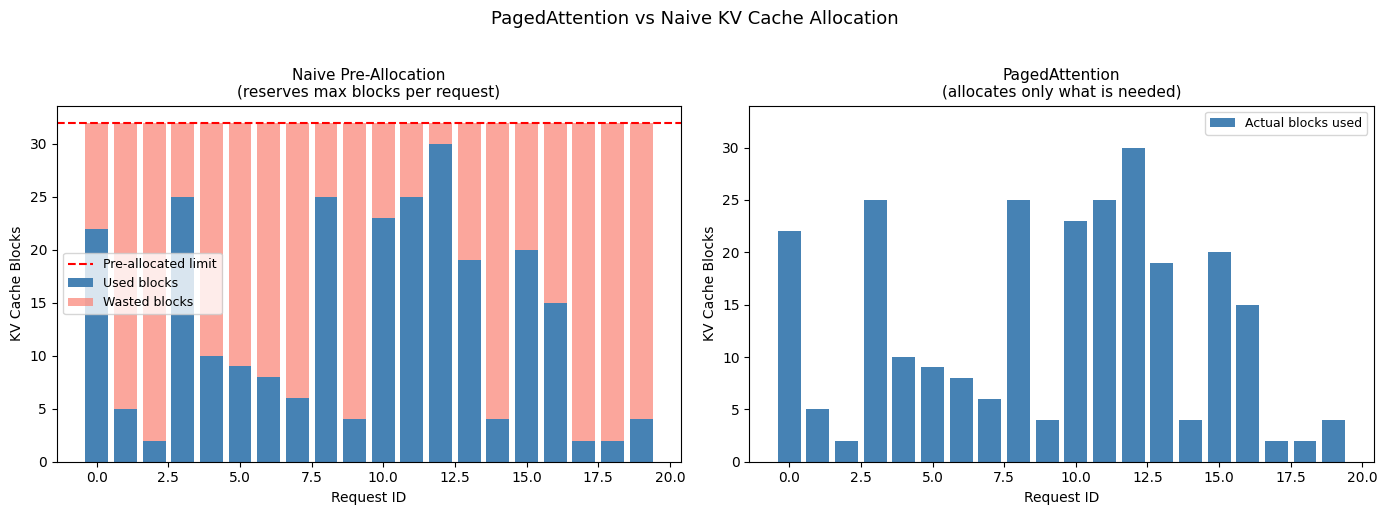

In [3]:
# Simulate a PagedAttention block manager

class BlockManager:
    """Simplified PagedAttention block manager."""
    def __init__(self, total_blocks=64, block_size=16):
        """
        total_blocks: total KV cache blocks available
        block_size: tokens per block
        """
        self.total_blocks = total_blocks
        self.block_size = block_size
        self.free_blocks = set(range(total_blocks))  # physical block IDs
        self.block_tables = {}  # request_id -> list of physical blocks

    @property
    def num_free_blocks(self):
        return len(self.free_blocks)

    def allocate(self, request_id, num_tokens):
        """Allocate blocks for a new request."""
        blocks_needed = (num_tokens + self.block_size - 1) // self.block_size
        if blocks_needed > len(self.free_blocks):
            return False  # OOM
        allocated = [self.free_blocks.pop() for _ in range(blocks_needed)]
        self.block_tables[request_id] = allocated
        return True

    def append_token(self, request_id):
        """Add one token to a request's sequence, allocating a new block if needed."""
        # Check if last block is full
        current_blocks = len(self.block_tables.get(request_id, []))
        # Count tokens in last block (simplified: track total tokens)
        if request_id not in self.block_tables:
            return self.allocate(request_id, 1)
        # Simplified: allocate new block every block_size tokens
        return True

    def free(self, request_id):
        """Free all blocks for a finished request."""
        if request_id in self.block_tables:
            self.free_blocks.update(self.block_tables.pop(request_id))

    def utilization(self):
        used = self.total_blocks - len(self.free_blocks)
        return used / self.total_blocks

# Compare: naive pre-allocation vs PagedAttention
import random
random.seed(42)

TOTAL_VRAM_BLOCKS = 1000  # represents available KV cache blocks
BLOCK_SIZE = 16  # tokens per block
MAX_SEQ = 512   # max sequence length in tokens

# Simulate 200 requests with random output lengths
requests = [(i, random.randint(10, MAX_SEQ)) for i in range(200)]

# Naive: pre-allocate max blocks for each request
max_blocks_per_req = (MAX_SEQ + BLOCK_SIZE - 1) // BLOCK_SIZE
naive_concurrent = TOTAL_VRAM_BLOCKS // max_blocks_per_req

# PagedAttention: allocate actual blocks needed
actual_blocks_avg = sum(r[1] for r in requests) / len(requests)
avg_blocks_per_req = (actual_blocks_avg + BLOCK_SIZE - 1) // BLOCK_SIZE
paged_concurrent = TOTAL_VRAM_BLOCKS / avg_blocks_per_req

print(f"KV Cache memory comparison (total: {TOTAL_VRAM_BLOCKS} blocks of {BLOCK_SIZE} tokens)")
print()
print(f"Naive pre-allocation:")
print(f"  Reserves {max_blocks_per_req} blocks per request (max possible)")
print(f"  Concurrent requests:  {naive_concurrent}")
print()
print(f"PagedAttention:")
print(f"  Allocates ~{avg_blocks_per_req:.1f} blocks per request (actual average)")
print(f"  Concurrent requests:  {paged_concurrent:.0f}  ({paged_concurrent/naive_concurrent:.1f}x more)")

# Visualize block allocation patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Naive: show wasted blocks
n_show = min(20, len(requests))
actual_lens = [r[1] for r in requests[:n_show]]
actual_blocks = [(l + BLOCK_SIZE - 1) // BLOCK_SIZE for l in actual_lens]
wasted = [max_blocks_per_req - ab for ab in actual_blocks]

x_pos = range(n_show)
axes[0].bar(x_pos, actual_blocks, label='Used blocks', color='steelblue')
axes[0].bar(x_pos, wasted, bottom=actual_blocks, label='Wasted blocks', color='salmon', alpha=0.7)
axes[0].axhline(y=max_blocks_per_req, color='red', linestyle='--', label='Pre-allocated limit')
axes[0].set_title('Naive Pre-Allocation\n(reserves max blocks per request)', fontsize=11)
axes[0].set_xlabel('Request ID')
axes[0].set_ylabel('KV Cache Blocks')
axes[0].legend(fontsize=9)

# PagedAttention: only actual blocks
axes[1].bar(x_pos, actual_blocks, color='steelblue', label='Actual blocks used')
axes[1].set_title('PagedAttention\n(allocates only what is needed)', fontsize=11)
axes[1].set_xlabel('Request ID')
axes[1].set_ylabel('KV Cache Blocks')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, max_blocks_per_req + 2)

plt.suptitle('PagedAttention vs Naive KV Cache Allocation', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Part 3: Continuous Batching

**Static batching:** Collect N requests, run them all to completion as a batch, then process the next batch. Problem: short requests must wait for the longest request to finish before the next batch starts. The GPU sits idle proportional to the variance in output lengths.

**Continuous batching:** After each token generation step, check:
- Did any request finish? Remove it from the batch.
- Is there a new request waiting? Add it to the batch.

The batch size stays near-constant, GPU utilization stays high.

Batching comparison (50 requests, batch_size=8)

Static batching:
  Total time:      2865 ms
  Throughput:      854 tokens/sec

Continuous batching:
  Total time:      1645 ms
  Throughput:      1487 tokens/sec
  Speedup:         1.74x


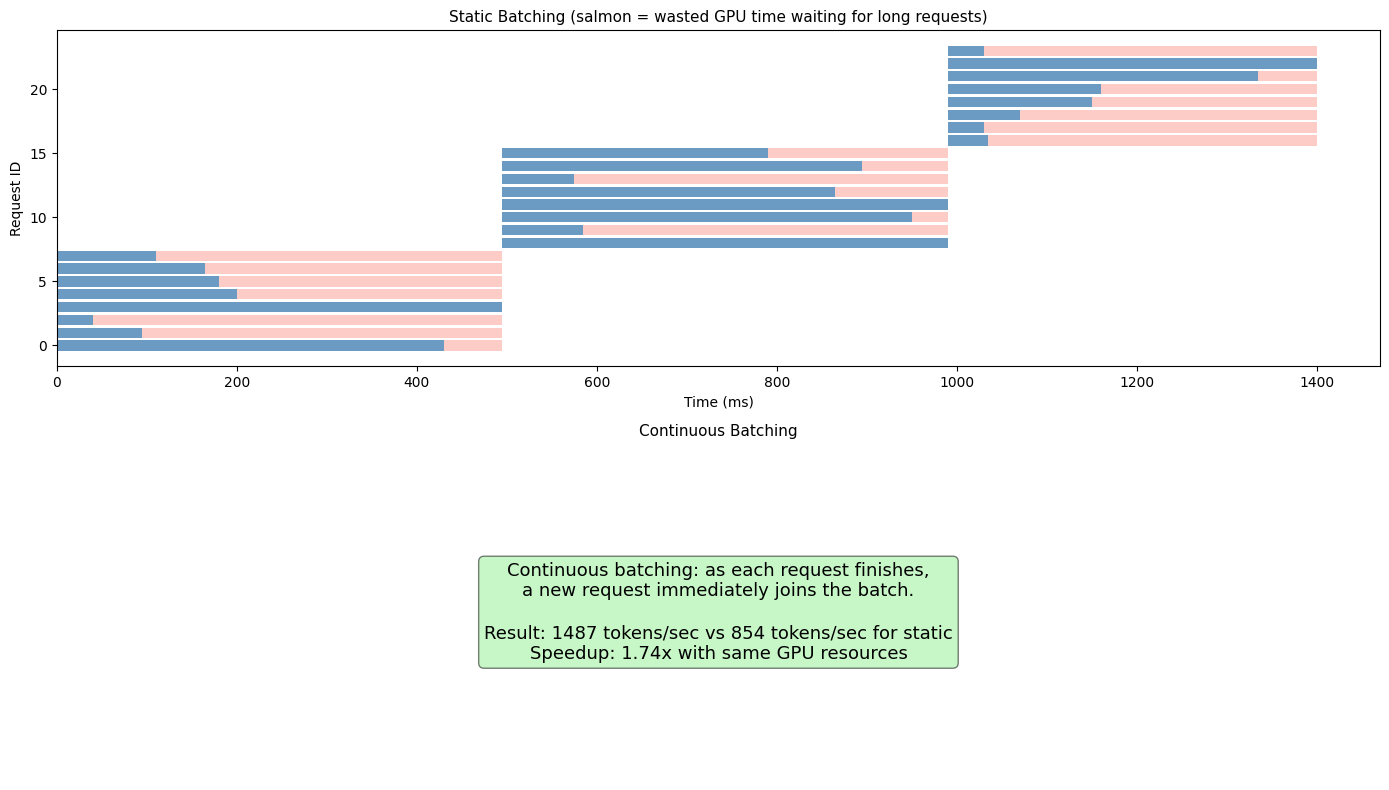

In [4]:
# Simulate static vs continuous batching throughput
import random
random.seed(42)

# Generate requests with random output lengths (simulating real traffic)
N_REQUESTS = 50
request_lengths = [random.randint(5, 100) for _ in range(N_REQUESTS)]
TOKENS_PER_STEP_MS = 5  # ms per token generation step
BATCH_SIZE = 8

# Static batching simulation
def simulate_static_batching(lengths, batch_size, ms_per_token):
    batches = [lengths[i:i+batch_size] for i in range(0, len(lengths), batch_size)]
    total_time = 0
    for batch in batches:
        # Batch runs until the LONGEST request finishes
        batch_time = max(batch) * ms_per_token
        total_time += batch_time
    total_tokens = sum(lengths)
    return total_time, total_tokens, total_tokens / total_time * 1000  # tokens/sec

# Continuous batching simulation
def simulate_continuous_batching(lengths, batch_size, ms_per_token):
    # Priority queue: (remaining_tokens, request_id)
    queue = deque(enumerate(lengths))
    active = []  # (remaining, req_id)
    total_time = 0
    total_tokens = sum(lengths)
    step_count = 0

    # Fill initial batch
    while queue and len(active) < batch_size:
        req_id, length = queue.popleft()
        active.append([length, req_id])

    while active:
        # Generate one token for all active requests
        total_time += ms_per_token
        step_count += 1

        # Decrement remaining tokens
        active = [[r - 1, rid] for r, rid in active]

        # Remove finished requests and add new ones
        finished = [i for i, (r, _) in enumerate(active) if r == 0]
        for i in sorted(finished, reverse=True):
            active.pop(i)
            if queue:
                req_id, length = queue.popleft()
                active.append([length, req_id])

    return total_time, total_tokens, total_tokens / total_time * 1000

static_time, static_tokens, static_tps = simulate_static_batching(request_lengths, BATCH_SIZE, TOKENS_PER_STEP_MS)
cont_time, cont_tokens, cont_tps = simulate_continuous_batching(request_lengths, BATCH_SIZE, TOKENS_PER_STEP_MS)

print(f"Batching comparison ({N_REQUESTS} requests, batch_size={BATCH_SIZE})")
print()
print(f"Static batching:")
print(f"  Total time:      {static_time:.0f} ms")
print(f"  Throughput:      {static_tps:.0f} tokens/sec")
print()
print(f"Continuous batching:")
print(f"  Total time:      {cont_time:.0f} ms")
print(f"  Throughput:      {cont_tps:.0f} tokens/sec")
print(f"  Speedup:         {static_time/cont_time:.2f}x")

# Visualize request timelines
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

def plot_static(ax, lengths, batch_size, ms_per_token):
    batches = [lengths[i:i+batch_size] for i in range(0, len(lengths), batch_size)]
    t = 0
    for bi, batch in enumerate(batches):
        max_len = max(batch)
        for ri, req_len in enumerate(batch):
            global_req = bi * batch_size + ri
            ax.barh(global_req, req_len * ms_per_token, left=t,
                    color='steelblue', alpha=0.8, height=0.8)
            # Show wasted wait time
            if req_len < max_len:
                ax.barh(global_req, (max_len - req_len) * ms_per_token,
                       left=t + req_len * ms_per_token,
                       color='salmon', alpha=0.4, height=0.8)
        t += max_len * ms_per_token
    ax.set_title('Static Batching (salmon = wasted GPU time waiting for long requests)', fontsize=11)
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Request ID')

plot_static(axes[0], request_lengths[:24], BATCH_SIZE, TOKENS_PER_STEP_MS)
axes[1].text(0.5, 0.5,
    "Continuous batching: as each request finishes,\n"
    "a new request immediately joins the batch.\n\n"
    f"Result: {cont_tps:.0f} tokens/sec vs {static_tps:.0f} tokens/sec for static\n"
    f"Speedup: {static_time/cont_time:.2f}x with same GPU resources",
    transform=axes[1].transAxes, fontsize=13, ha='center', va='center',
    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
axes[1].axis('off')
axes[1].set_title('Continuous Batching', fontsize=11)

plt.tight_layout()
plt.show()

## Try These Experiments

1. **Block table visualization:** Modify the `BlockManager` to track which physical block addresses each request is using. Print the block table after allocating 5 requests with different lengths. Show how blocks are reused when requests finish.

2. **Batch size effect:** In the continuous batching simulation, sweep batch sizes from 1 to 32. Plot throughput vs batch size. Is there a point of diminishing returns? Why?

3. **Prefix sharing:** Two requests start with identical 100-token system prompts. With PagedAttention prefix sharing, how many blocks can be shared? Calculate the memory savings as a percentage for the LLaMA 3 8B configuration.

## Key Takeaways

- **PagedAttention** applies OS virtual memory concepts to the KV cache: fixed-size blocks, non-contiguous allocation, block tables for lookup. Eliminates both internal and external fragmentation.
- **Continuous batching** operates at the token level — finished requests are replaced immediately. No GPU idle time waiting for batch stragglers.
- Together, these two innovations gave vLLM the largest market share among inference engines.
- The memory savings from PagedAttention are most significant when request length variance is high (short and long requests mixed).
- **What's next:** Day 10 — SGLang: RadixAttention and structured outputs — how SGLang pushes prefix caching further.

## References
- *Inference Engineering* Ch 4.3.1 (pp. 106–108) — vLLM